In [2]:
# ============================================================
# CELL 1: Imports & Configuration
# PURPOSE: Load all libraries we need for EDA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os
import warnings

warnings.filterwarnings("ignore")

# ── Load DB credentials from .env ──
load_dotenv("../.env")
engine = create_engine(
    f"mysql+pymysql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}",
    echo=False
)

# ── Global chart style for all plots ──
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)
plt.rcParams["figure.dpi"]         = 150
plt.rcParams["figure.figsize"]     = (12, 5)
plt.rcParams["axes.spines.top"]    = False
plt.rcParams["axes.spines.right"]  = False

print("✅ Libraries loaded successfully")
print(f"   Pandas:     {pd.__version__}")
print(f"   NumPy:      {np.__version__}")
print(f"   Seaborn:    {sns.__version__}")

✅ Libraries loaded successfully
   Pandas:     3.0.3
   NumPy:      2.4.4
   Seaborn:    0.13.2


In [3]:
# ============================================================
# CELL 2: Load Data from MySQL
# PURPOSE: Pull all 4 tables into Pandas DataFrames
# ============================================================

# ── Load all 4 tables from MySQL ──
print("📦 Loading data from MySQL...")

df_orders = pd.read_sql("""
    SELECT
        fo.*,
        dc.customer_fname,
        dc.customer_lname,
        dc.customer_segment,
        dc.customer_city,
        dc.customer_country,
        dp.product_name,
        dp.product_category,
        dp.department_name,
        ds.market,
        ds.order_region,
        ds.shipping_mode
    FROM fact_orders fo
    JOIN dim_customer dc ON fo.customer_id = dc.customer_id
    JOIN dim_product  dp ON fo.product_id  = dp.product_id
    JOIN dim_supplier ds ON fo.supplier_id = ds.supplier_id
""", engine)

print(f"✅ Loaded {len(df_orders):,} rows × {len(df_orders.columns)} columns")

# ── Quick peek at the data ──
print("\n📋 Column names:")
print(df_orders.columns.tolist())

print("\n🔍 First 3 rows:")
df_orders.head(3)

📦 Loading data from MySQL...
✅ Loaded 180,519 rows × 27 columns

📋 Column names:
['order_item_id', 'order_id', 'customer_id', 'product_id', 'supplier_id', 'order_date', 'shipping_date', 'scheduled_ship_days', 'actual_ship_days', 'sales_per_order', 'order_profit_per_order', 'order_item_discount', 'order_item_quantity', 'is_delayed', 'delivery_status', 'late_delivery_risk', 'customer_fname', 'customer_lname', 'customer_segment', 'customer_city', 'customer_country', 'product_name', 'product_category', 'department_name', 'market', 'order_region', 'shipping_mode']

🔍 First 3 rows:


,order_item_id,order_id,customer_id,product_id,supplier_id,order_date,shipping_date,scheduled_ship_days,actual_ship_days,sales_per_order,...,customer_lname,customer_segment,customer_city,customer_country,product_name,product_category,department_name,market,order_region,shipping_mode
0,1,77202,1,1,1,2018-01-31,2018-02-03,4,3,327.75,...,Holloway,Consumer,Caguas,Puerto Rico,Smart watch,Sporting Goods,Fitness,Pacific Asia,Southeast Asia,Standard Class
1,2,75939,2,1,2,2018-01-13,2018-01-18,4,5,327.75,...,Luna,Consumer,Caguas,Puerto Rico,Smart watch,Sporting Goods,Fitness,Pacific Asia,South Asia,Standard Class
2,3,75938,3,1,2,2018-01-13,2018-01-17,4,4,327.75,...,Maldonado,Consumer,San Jose,EE. UU.,Smart watch,Sporting Goods,Fitness,Pacific Asia,South Asia,Standard Class


In [4]:
# ============================================================
# CELL 3: Data Quality Check
# PURPOSE: Understand the shape, nulls, and data types
#          before any analysis — always do this first
# ============================================================

print("=" * 55)
print("📊 DATASET OVERVIEW")
print("=" * 55)
print(f"Rows:    {len(df_orders):,}")
print(f"Columns: {len(df_orders.columns)}")

print("\n" + "=" * 55)
print("📋 DATA TYPES")
print("=" * 55)
print(df_orders.dtypes)

print("\n" + "=" * 55)
print("🔍 MISSING VALUES")
print("=" * 55)
missing = df_orders.isnull().sum()
missing_pct = (missing / len(df_orders) * 100).round(2)
missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_pct":   missing_pct
}).query("missing_count > 0").sort_values("missing_pct", ascending=False)

if len(missing_df) == 0:
    print("✅ No missing values found!")
else:
    print(missing_df)

print("\n" + "=" * 55)
print("📈 NUMERICAL SUMMARY")
print("=" * 55)
df_orders[[
    "sales_per_order",
    "order_profit_per_order",
    "order_item_discount",
    "scheduled_ship_days",
    "actual_ship_days",
    "is_delayed"
]].describe().round(2)

📊 DATASET OVERVIEW
Rows:    180,519
Columns: 27

📋 DATA TYPES
order_item_id               int64
order_id                    int64
customer_id                 int64
product_id                  int64
supplier_id                 int64
order_date                 object
shipping_date              object
scheduled_ship_days         int64
actual_ship_days            int64
sales_per_order           float64
order_profit_per_order    float64
order_item_discount       float64
order_item_quantity         int64
is_delayed                  int64
delivery_status               str
late_delivery_risk          int64
customer_fname                str
customer_lname                str
customer_segment              str
customer_city                 str
customer_country              str
product_name                  str
product_category              str
department_name               str
market                        str
order_region                  str
shipping_mode                 str
dtype: object

🔍 MIS

,sales_per_order,order_profit_per_order,order_item_discount,scheduled_ship_days,actual_ship_days,is_delayed
count,180519.00,180519.00,180519.00,180519.00,180519.00,180519.00
mean,203.77,21.97,20.66,2.93,3.50,0.57
std,132.27,104.43,21.80,1.37,1.62,0.49
min,9.99,-4274.98,0.00,0.00,0.00,0.00
25%,119.98,7.00,5.40,2.00,2.00,0.00
50%,199.92,31.52,14.00,4.00,3.00,1.00
75%,299.95,64.80,29.99,4.00,5.00,1.00
max,1999.99,911.80,500.00,4.00,6.00,1.00


In [5]:
# ============================================================
# CELL 4: Data Cleaning
# PURPOSE: Fix data types, handle nulls, engineer new features
#          that will power our Tableau dashboard
# ============================================================

print("🔧 Starting data cleaning...")
df = df_orders.copy()  # always work on a copy, never the original

# ── 1. Fix date columns ──
# Ensure proper datetime format for time-series analysis
df["order_date"]   = pd.to_datetime(df["order_date"])
df["shipping_date"] = pd.to_datetime(df["shipping_date"])

# ── 2. Extract time features ──
# These become filter dimensions in Tableau
df["order_year"]    = df["order_date"].dt.year
df["order_month"]   = df["order_date"].dt.month
df["order_month_name"] = df["order_date"].dt.strftime("%b")
df["order_quarter"] = df["order_date"].dt.quarter
df["order_dayofweek"] = df["order_date"].dt.day_name()

# ── 3. Engineer delay_days column ──
# How many days late was each shipment?
# Negative = early, Positive = late, Zero = on time
df["delay_days"] = df["actual_ship_days"] - df["scheduled_ship_days"]

# ── 4. Engineer profit margin % ──
# Core KPI for the CFO dashboard
df["profit_margin_pct"] = (
    df["order_profit_per_order"] /
    df["sales_per_order"].replace(0, np.nan) * 100
).round(2)

# ── 5. Engineer revenue bands ──
# Segments orders into size buckets for drill-down analysis
df["revenue_band"] = pd.cut(
    df["sales_per_order"],
    bins=[0, 50, 150, 300, 500, float("inf")],
    labels=["<$50", "$50-150", "$150-300", "$300-500", "$500+"]
)

# ── 6. Clean delivery_status ──
# Standardise casing for consistent grouping
df["delivery_status"] = df["delivery_status"].str.strip().str.title()

# ── 7. Drop any rows with null order dates ──
# These can't be used in time series analysis
before = len(df)
df = df.dropna(subset=["order_date", "shipping_date"])
after = len(df)
print(f"   Dropped {before - after} rows with null dates")

# ── 8. Save cleaned data to processed folder ──
PROCESSED_PATH = "../data/processed/supply_chain_cleaned.csv"
df.to_csv(PROCESSED_PATH, index=False)
print(f"   ✅ Cleaned data saved to {PROCESSED_PATH}")

# ── Summary of new features ──
print("\n✅ Cleaning complete. New features added:")
print(f"   order_year, order_month, order_quarter")
print(f"   order_dayofweek, delay_days")
print(f"   profit_margin_pct, revenue_band")
print(f"\n   Final shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

🔧 Starting data cleaning...
   Dropped 0 rows with null dates
   ✅ Cleaned data saved to ../data/processed/supply_chain_cleaned.csv

✅ Cleaning complete. New features added:
   order_year, order_month, order_quarter
   order_dayofweek, delay_days
   profit_margin_pct, revenue_band

   Final shape: 180,519 rows × 35 columns


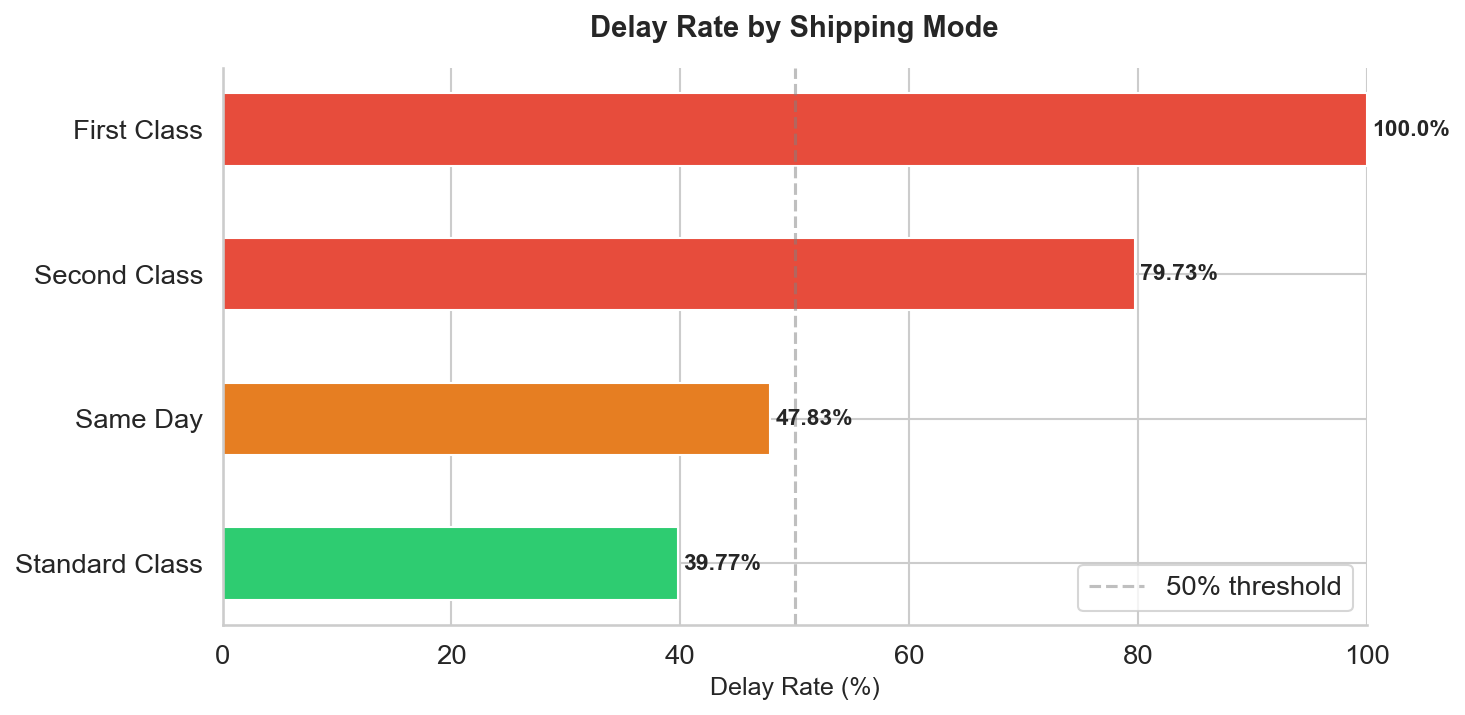

✅ Chart saved to images/


In [6]:
# ============================================================
# CELL 5: EDA Chart 1 — Delay Rate by Shipping Mode
# BUSINESS QUESTION: Which shipping mode causes the most delays?
# CHART TYPE: Horizontal bar chart
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

# ── Aggregate delay rate by shipping mode ──
delay_by_mode = (
    df.groupby("shipping_mode")["is_delayed"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=True)
    .reset_index()
)
delay_by_mode.columns = ["shipping_mode", "delay_rate_pct"]

# ── Color bars by severity ──
colors = ["#2ecc71" if x < 40 else "#e67e22" if x < 60 else "#e74c3c"
          for x in delay_by_mode["delay_rate_pct"]]

bars = ax.barh(
    delay_by_mode["shipping_mode"],
    delay_by_mode["delay_rate_pct"],
    color=colors, edgecolor="white", height=0.5
)

# ── Add value labels on bars ──
for bar, val in zip(bars, delay_by_mode["delay_rate_pct"]):
    ax.text(
        bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
        f"{val}%", va="center", fontsize=11, fontweight="bold"
    )

ax.set_xlabel("Delay Rate (%)", fontsize=12)
ax.set_title("Delay Rate by Shipping Mode", fontsize=14, fontweight="bold", pad=15)
ax.set_xlim(0, 100)
ax.axvline(x=50, color="gray", linestyle="--", alpha=0.5, label="50% threshold")
ax.legend()

plt.tight_layout()
plt.savefig("../images/01_delay_by_shipping_mode.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved to images/")

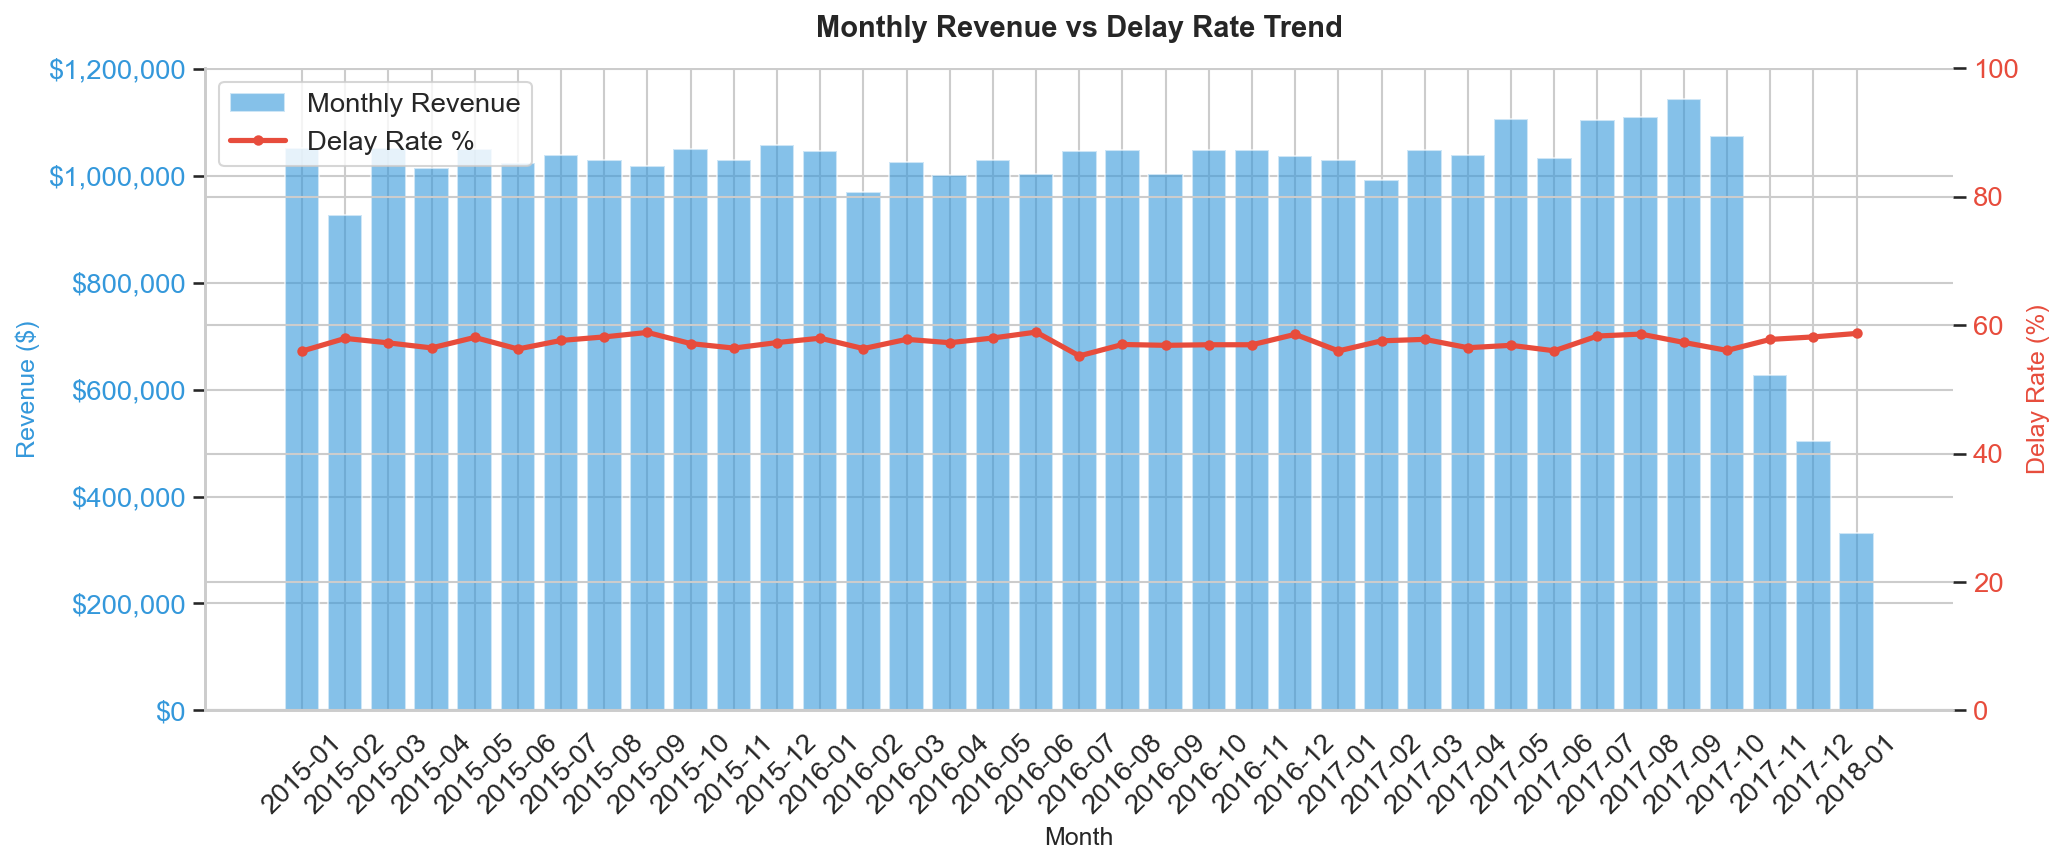

✅ Chart saved to images/


In [7]:
# ============================================================
# CELL 6: EDA Chart 2 — Monthly Revenue & Delay Trend
# BUSINESS QUESTION: Is revenue growing? Does delay rate
# correlate with revenue drops over time?
# CHART TYPE: Dual axis line chart
# ============================================================

fig, ax1 = plt.subplots(figsize=(14, 6))

# ── Aggregate monthly metrics ──
monthly = (
    df.groupby(["order_year", "order_month"])
    .agg(
        total_revenue   = ("sales_per_order",        "sum"),
        total_profit    = ("order_profit_per_order",  "sum"),
        delay_rate_pct  = ("is_delayed",              "mean")
    )
    .reset_index()
)
monthly["delay_rate_pct"] = (monthly["delay_rate_pct"] * 100).round(2)
monthly["total_revenue"]  = monthly["total_revenue"].round(2)

# Create a readable date label for x axis
monthly["month_label"] = (
    monthly["order_year"].astype(str) + "-" +
    monthly["order_month"].astype(str).str.zfill(2)
)

# ── Primary axis: Revenue bars ──
ax1.bar(
    monthly["month_label"],
    monthly["total_revenue"],
    color="#3498db", alpha=0.6,
    label="Monthly Revenue"
)
ax1.set_xlabel("Month", fontsize=12)
ax1.set_ylabel("Revenue ($)", fontsize=12, color="#3498db")
ax1.tick_params(axis="y", labelcolor="#3498db")
ax1.tick_params(axis="x", rotation=45)

# Format y axis as dollar amounts
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x:,.0f}")
)

# ── Secondary axis: Delay rate line ──
ax2 = ax1.twinx()
ax2.plot(
    monthly["month_label"],
    monthly["delay_rate_pct"],
    color="#e74c3c", linewidth=2.5,
    marker="o", markersize=4,
    label="Delay Rate %"
)
ax2.set_ylabel("Delay Rate (%)", fontsize=12, color="#e74c3c")
ax2.tick_params(axis="y", labelcolor="#e74c3c")
ax2.set_ylim(0, 100)

# ── Combined legend ──
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

ax1.set_title(
    "Monthly Revenue vs Delay Rate Trend",
    fontsize=14, fontweight="bold", pad=15
)

plt.tight_layout()
plt.savefig("../images/02_monthly_revenue_delay_trend.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved to images/")

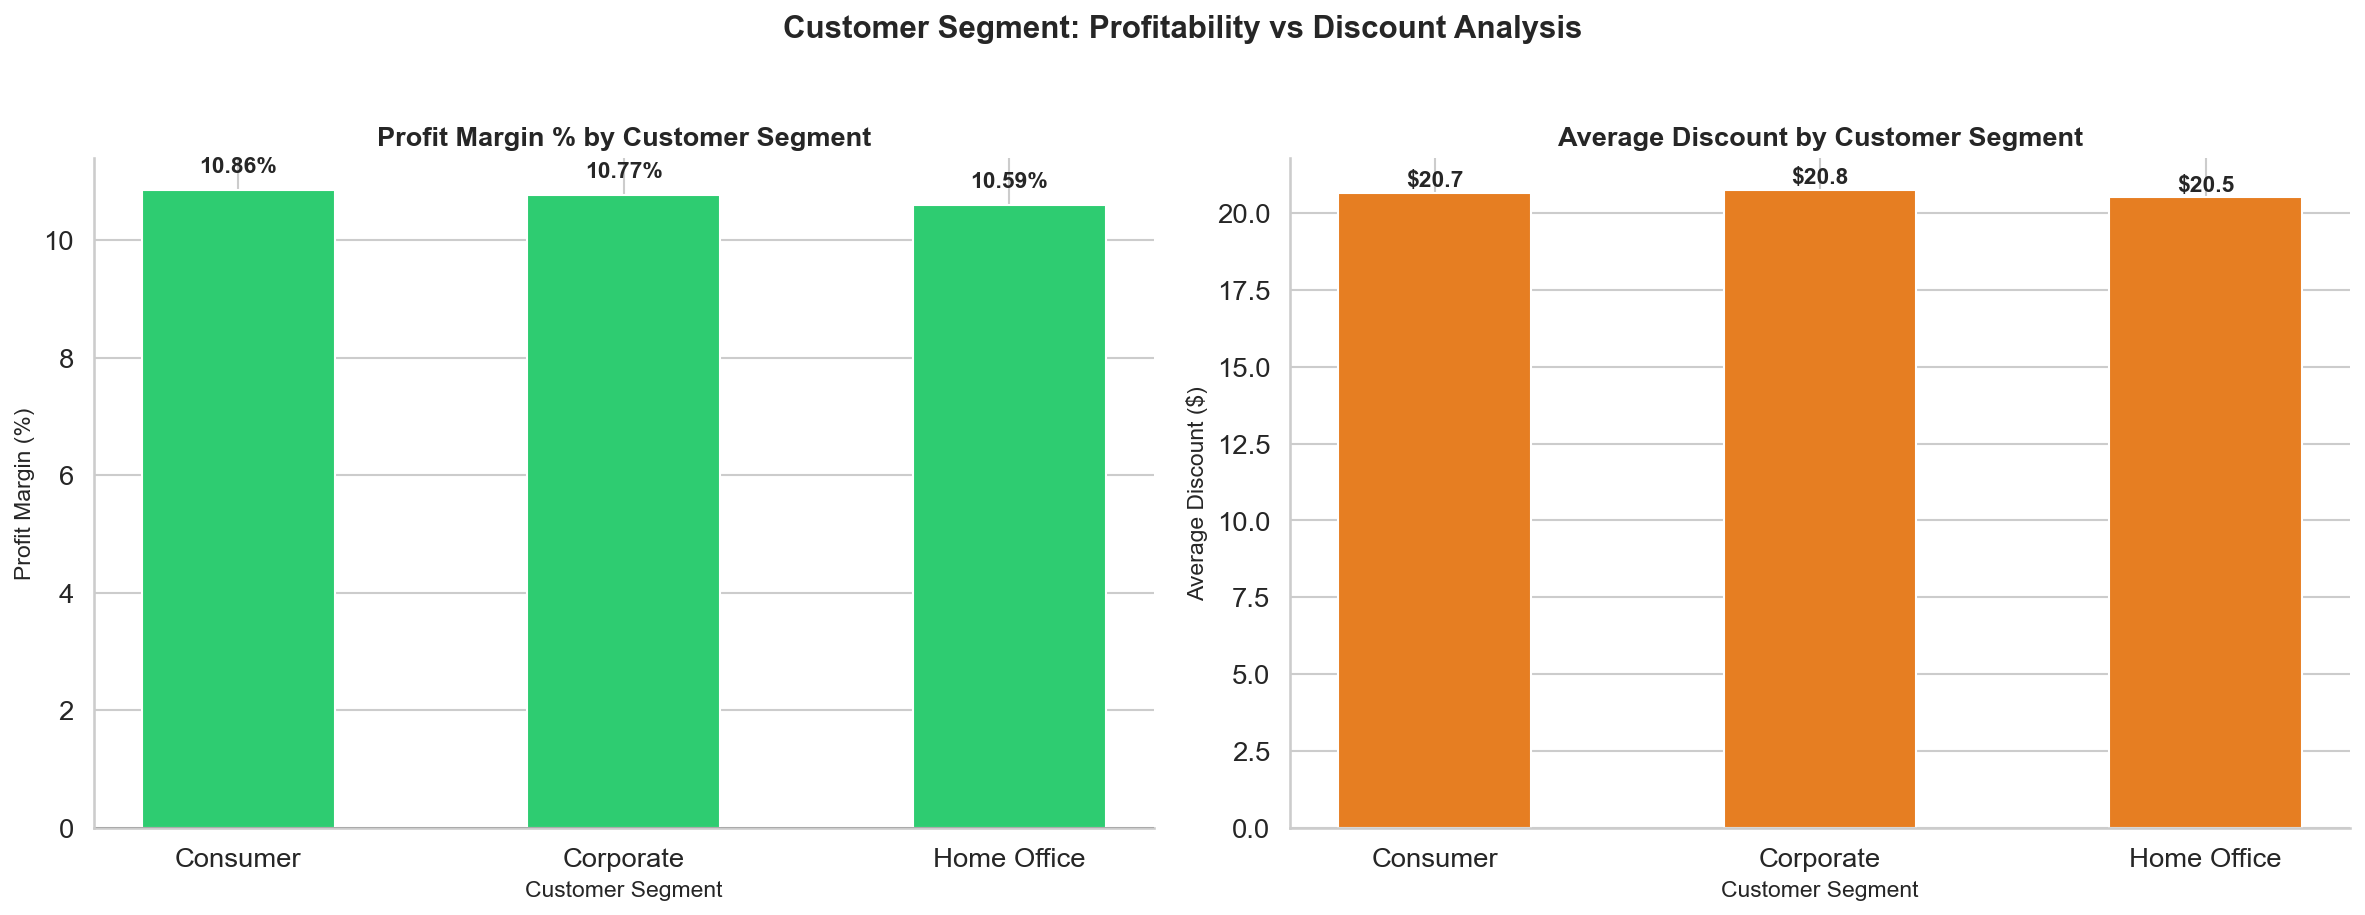

✅ Chart saved to images/


In [8]:
# ============================================================
# CELL 7: EDA Chart 3 — Profit Margin by Customer Segment
# BUSINESS QUESTION: Which customer segment is most profitable?
# Are heavy discounts hurting margin in any segment?
# CHART TYPE: Grouped bar chart
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── LEFT CHART: Profit margin % by segment ──
segment_margin = (
    df.groupby("customer_segment")
    .agg(
        total_revenue  = ("sales_per_order",        "sum"),
        total_profit   = ("order_profit_per_order",  "sum"),
        avg_discount   = ("order_item_discount",     "mean"),
        order_count    = ("order_id",                "count")
    )
    .reset_index()
)
segment_margin["profit_margin_pct"] = (
    segment_margin["total_profit"] /
    segment_margin["total_revenue"] * 100
).round(2)

colors = ["#2ecc71" if x > 0 else "#e74c3c"
          for x in segment_margin["profit_margin_pct"]]

bars = axes[0].bar(
    segment_margin["customer_segment"],
    segment_margin["profit_margin_pct"],
    color=colors, edgecolor="white", width=0.5
)

# Add value labels on top of bars
for bar, val in zip(bars, segment_margin["profit_margin_pct"]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{val}%", ha="center",
        fontsize=11, fontweight="bold"
    )

axes[0].set_title(
    "Profit Margin % by Customer Segment",
    fontsize=13, fontweight="bold"
)
axes[0].set_xlabel("Customer Segment", fontsize=11)
axes[0].set_ylabel("Profit Margin (%)", fontsize=11)
axes[0].axhline(y=0, color="black", linewidth=0.8)

# ── RIGHT CHART: Avg discount by segment ──
axes[1].bar(
    segment_margin["customer_segment"],
    segment_margin["avg_discount"],
    color="#e67e22", edgecolor="white", width=0.5
)

for i, (seg, disc) in enumerate(
    zip(segment_margin["customer_segment"],
        segment_margin["avg_discount"])
):
    axes[1].text(
        i, disc + 0.2,
        f"${disc:.1f}", ha="center",
        fontsize=11, fontweight="bold"
    )

axes[1].set_title(
    "Average Discount by Customer Segment",
    fontsize=13, fontweight="bold"
)
axes[1].set_xlabel("Customer Segment", fontsize=11)
axes[1].set_ylabel("Average Discount ($)", fontsize=11)

plt.suptitle(
    "Customer Segment: Profitability vs Discount Analysis",
    fontsize=15, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("../images/03_profit_margin_by_segment.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved to images/")

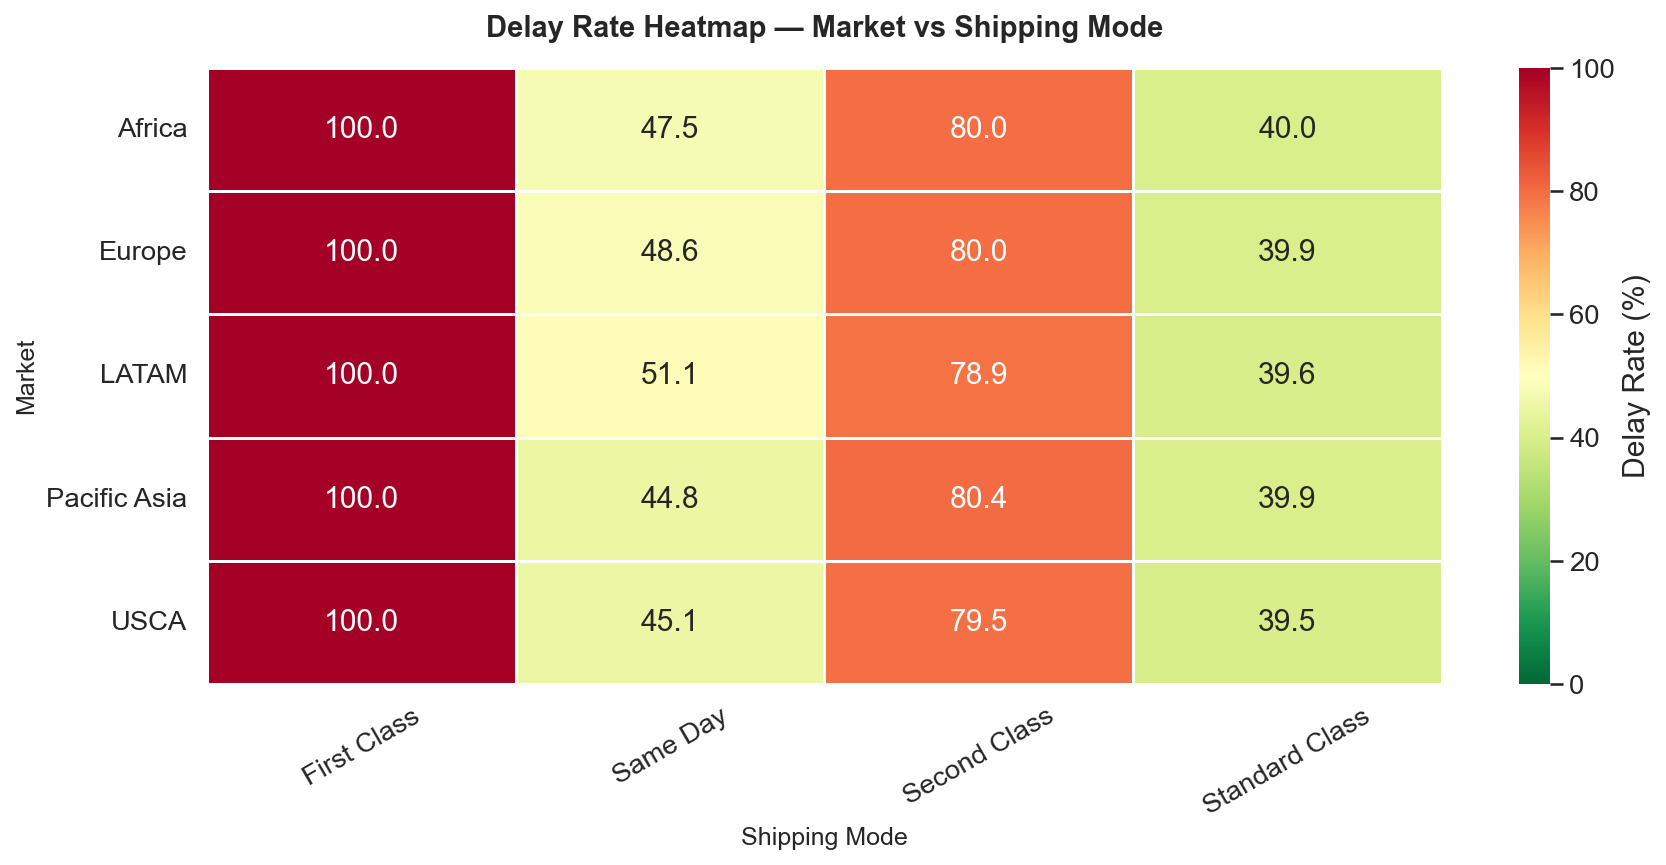

✅ Chart saved to images/


In [9]:
# ============================================================
# CELL 8: EDA Chart 4 — Delay Rate Heatmap by Market & Shipping
# BUSINESS QUESTION: Which market + shipping mode combination
# has the worst delay problem?
# CHART TYPE: Seaborn heatmap
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

# ── Pivot table: market vs shipping mode ──
# Values = average delay rate %
heatmap_data = (
    df.groupby(["market", "shipping_mode"])["is_delayed"]
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
    .pivot(index="market", columns="shipping_mode", values="is_delayed")
)

# ── Draw heatmap ──
sns.heatmap(
    heatmap_data,
    annot=True,           # show values inside cells
    fmt=".1f",            # 1 decimal place
    cmap="RdYlGn_r",      # red = high delay, green = low delay
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Delay Rate (%)"},
    ax=ax,
    vmin=0, vmax=100
)

ax.set_title(
    "Delay Rate Heatmap — Market vs Shipping Mode",
    fontsize=14, fontweight="bold", pad=15
)
ax.set_xlabel("Shipping Mode", fontsize=12)
ax.set_ylabel("Market", fontsize=12)
ax.tick_params(axis="x", rotation=30)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.savefig("../images/04_delay_heatmap_market_shipping.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved to images/")

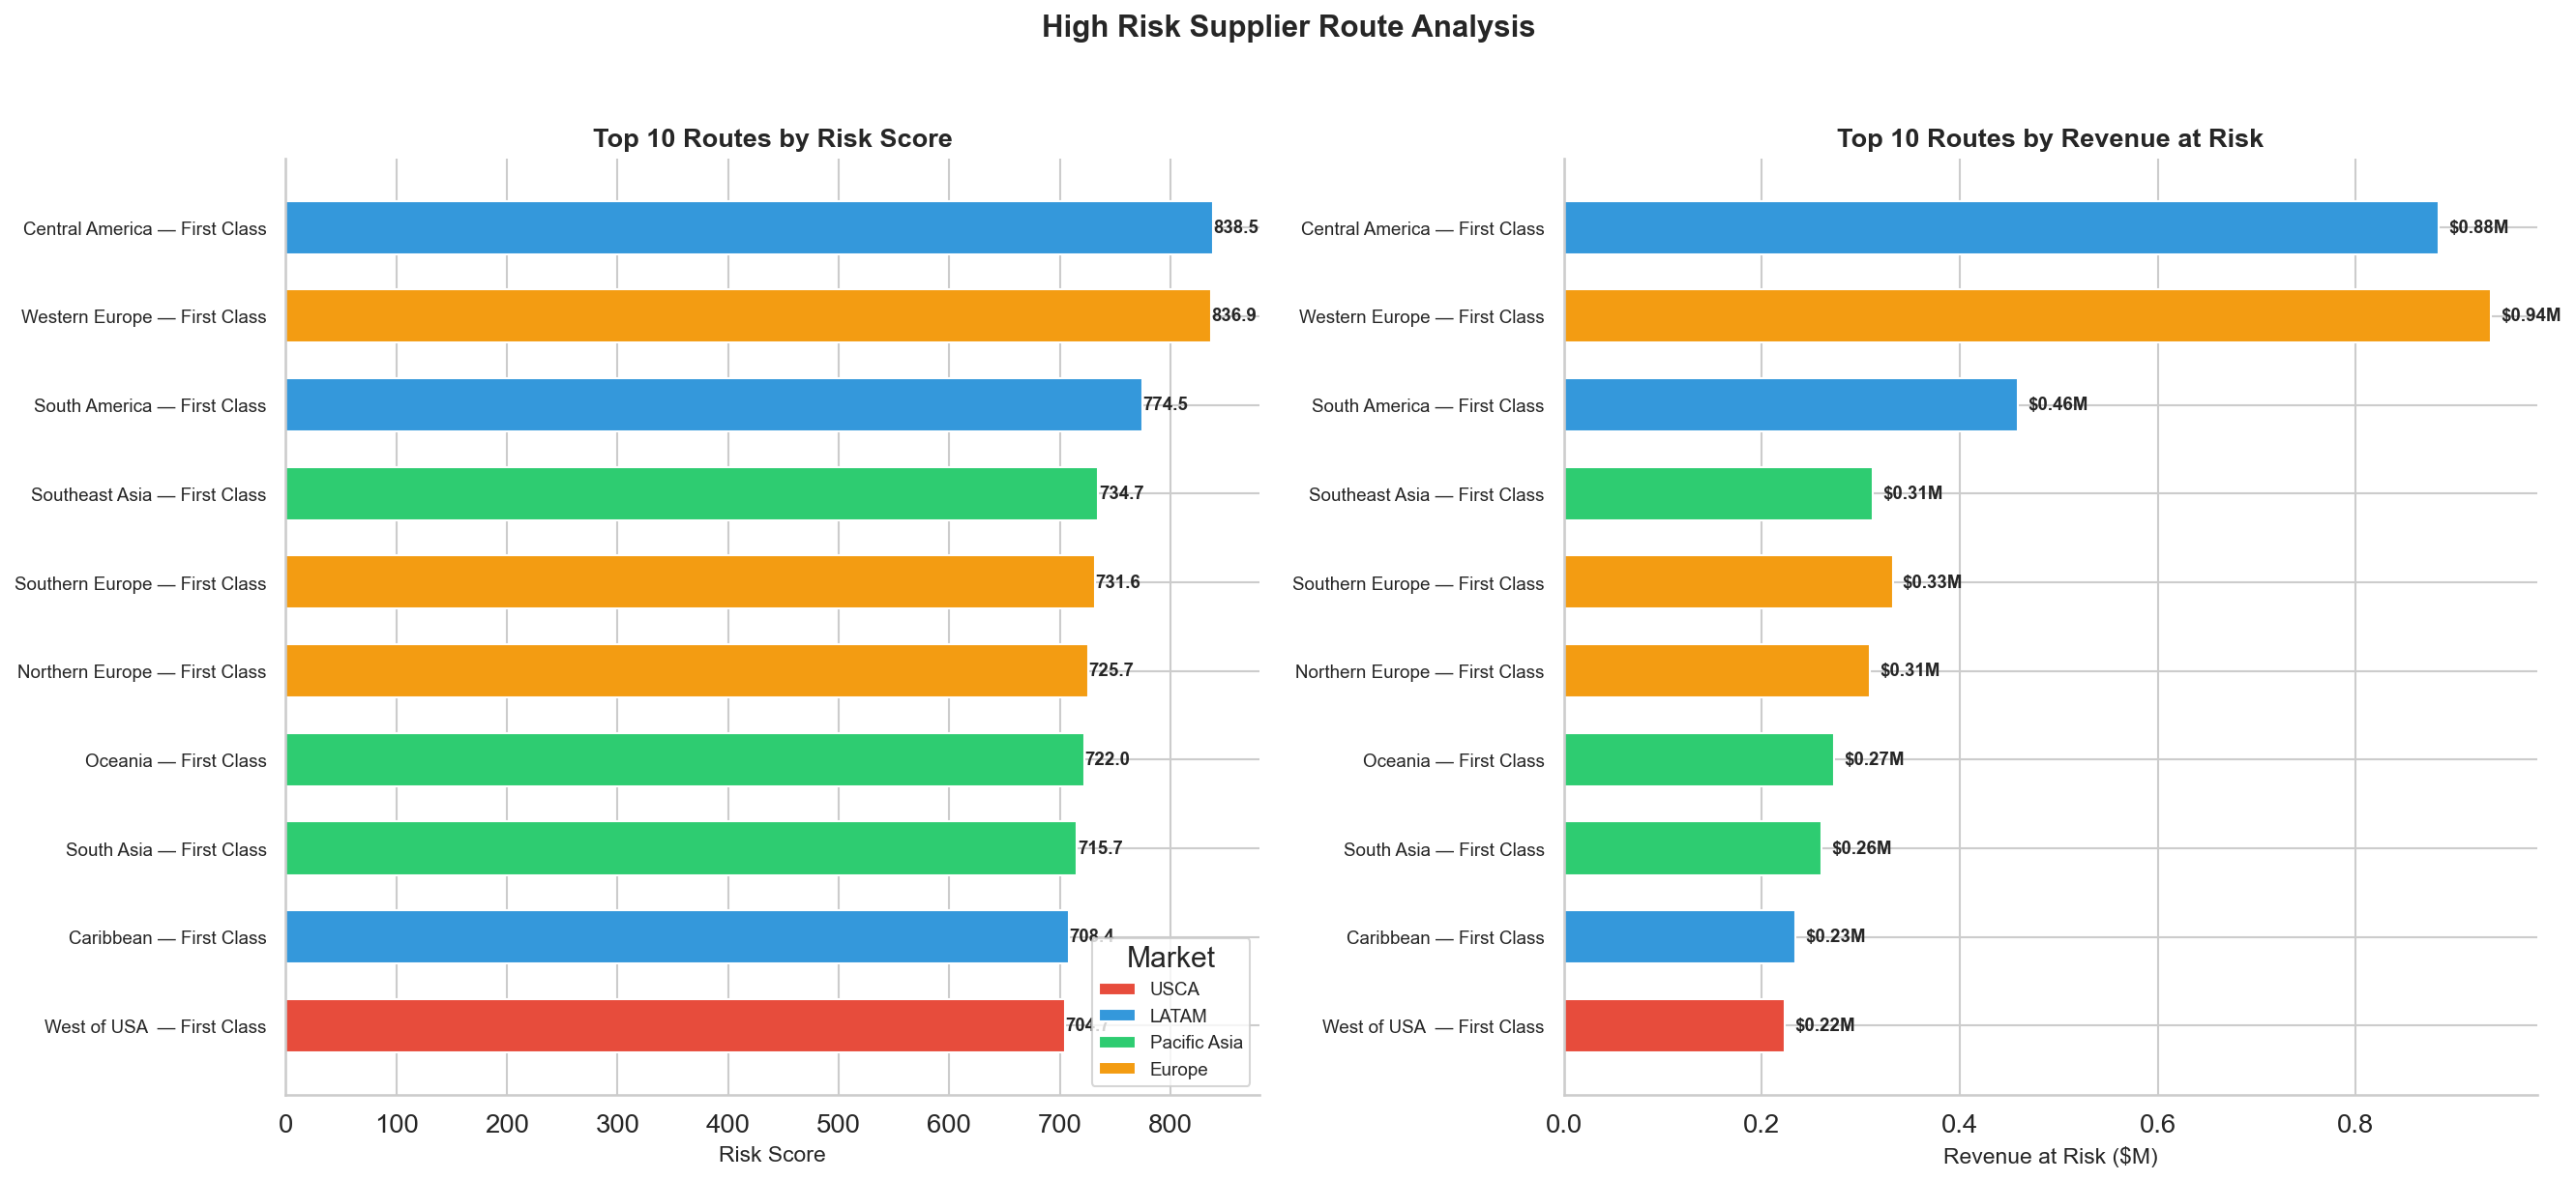

✅ Chart saved to images/


In [10]:
# ============================================================
# CELL 9: EDA Chart 5 — Top 10 High Risk Supplier Routes
# BUSINESS QUESTION: Which supplier routes have BOTH high
# delay rate AND high order volume? These need immediate action.
# FIX: Switched to horizontal bar chart — bubble chart was
#      unreadable due to all points clustering at 100% delay
# CHART TYPE: Dual horizontal bar chart
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# ── Aggregate supplier route metrics ──
supplier_risk = (
    df.groupby(["market", "order_region", "shipping_mode"])
    .agg(
        total_orders   = ("order_id",        "count"),
        delay_rate_pct = ("is_delayed",      "mean"),
        total_revenue  = ("sales_per_order", "sum"),
        avg_days_late  = ("delay_days",      "mean")
    )
    .reset_index()
)
supplier_risk["delay_rate_pct"] = (
    supplier_risk["delay_rate_pct"] * 100
).round(2)

# ── Risk score = delay rate × log(volume) ──
# Penalises high-volume delays more than low-volume ones
supplier_risk["risk_score"] = (
    supplier_risk["delay_rate_pct"] *
    np.log(supplier_risk["total_orders"])
).round(2)

# ── Revenue at risk = revenue × delay rate ──
supplier_risk["revenue_at_risk"] = (
    supplier_risk["total_revenue"] *
    supplier_risk["delay_rate_pct"] / 100
).round(2)

# ── Filter high volume routes only ──
supplier_risk = supplier_risk[supplier_risk["total_orders"] > 100]

# ── Top 10 by risk score ──
top10 = supplier_risk.nlargest(10, "risk_score").copy()
top10["route_label"] = (
    top10["order_region"] + " — " + top10["shipping_mode"]
)
# Sort ascending so highest risk appears at top
top10 = top10.sort_values("risk_score", ascending=True)

# ── Color by market ──
markets = top10["market"].unique()
palette = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12", "#9b59b6"]
color_map = {m: palette[i] for i, m in enumerate(markets)}
colors = top10["market"].map(color_map)

# ── LEFT CHART: Risk Score ──
bars1 = axes[0].barh(
    top10["route_label"],
    top10["risk_score"],
    color=colors,
    edgecolor="white",
    height=0.6
)

# Add value labels on each bar
for bar, val in zip(bars1, top10["risk_score"]):
    axes[0].text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}",
        va="center", fontsize=9, fontweight="bold"
    )

axes[0].set_xlabel("Risk Score", fontsize=11)
axes[0].set_title(
    "Top 10 Routes by Risk Score",
    fontsize=13, fontweight="bold"
)
axes[0].tick_params(axis="y", labelsize=9)

# Market legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=color_map[m], label=m) for m in markets
]
axes[0].legend(
    handles=legend_elements,
    title="Market", loc="lower right", fontsize=9
)

# ── RIGHT CHART: Revenue at Risk ──
bars2 = axes[1].barh(
    top10["route_label"],
    top10["revenue_at_risk"] / 1_000_000,
    color=colors,
    edgecolor="white",
    height=0.6
)

# Add value labels
for bar, val in zip(bars2, top10["revenue_at_risk"]):
    axes[1].text(
        bar.get_width() + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"${val/1_000_000:.2f}M",
        va="center", fontsize=9, fontweight="bold"
    )

axes[1].set_xlabel("Revenue at Risk ($M)", fontsize=11)
axes[1].set_title(
    "Top 10 Routes by Revenue at Risk",
    fontsize=13, fontweight="bold"
)
axes[1].tick_params(axis="y", labelsize=9)

plt.suptitle(
    "High Risk Supplier Route Analysis",
    fontsize=15, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig(
    "../images/05_top10_high_risk_supplier_routes.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("✅ Chart saved to images/")

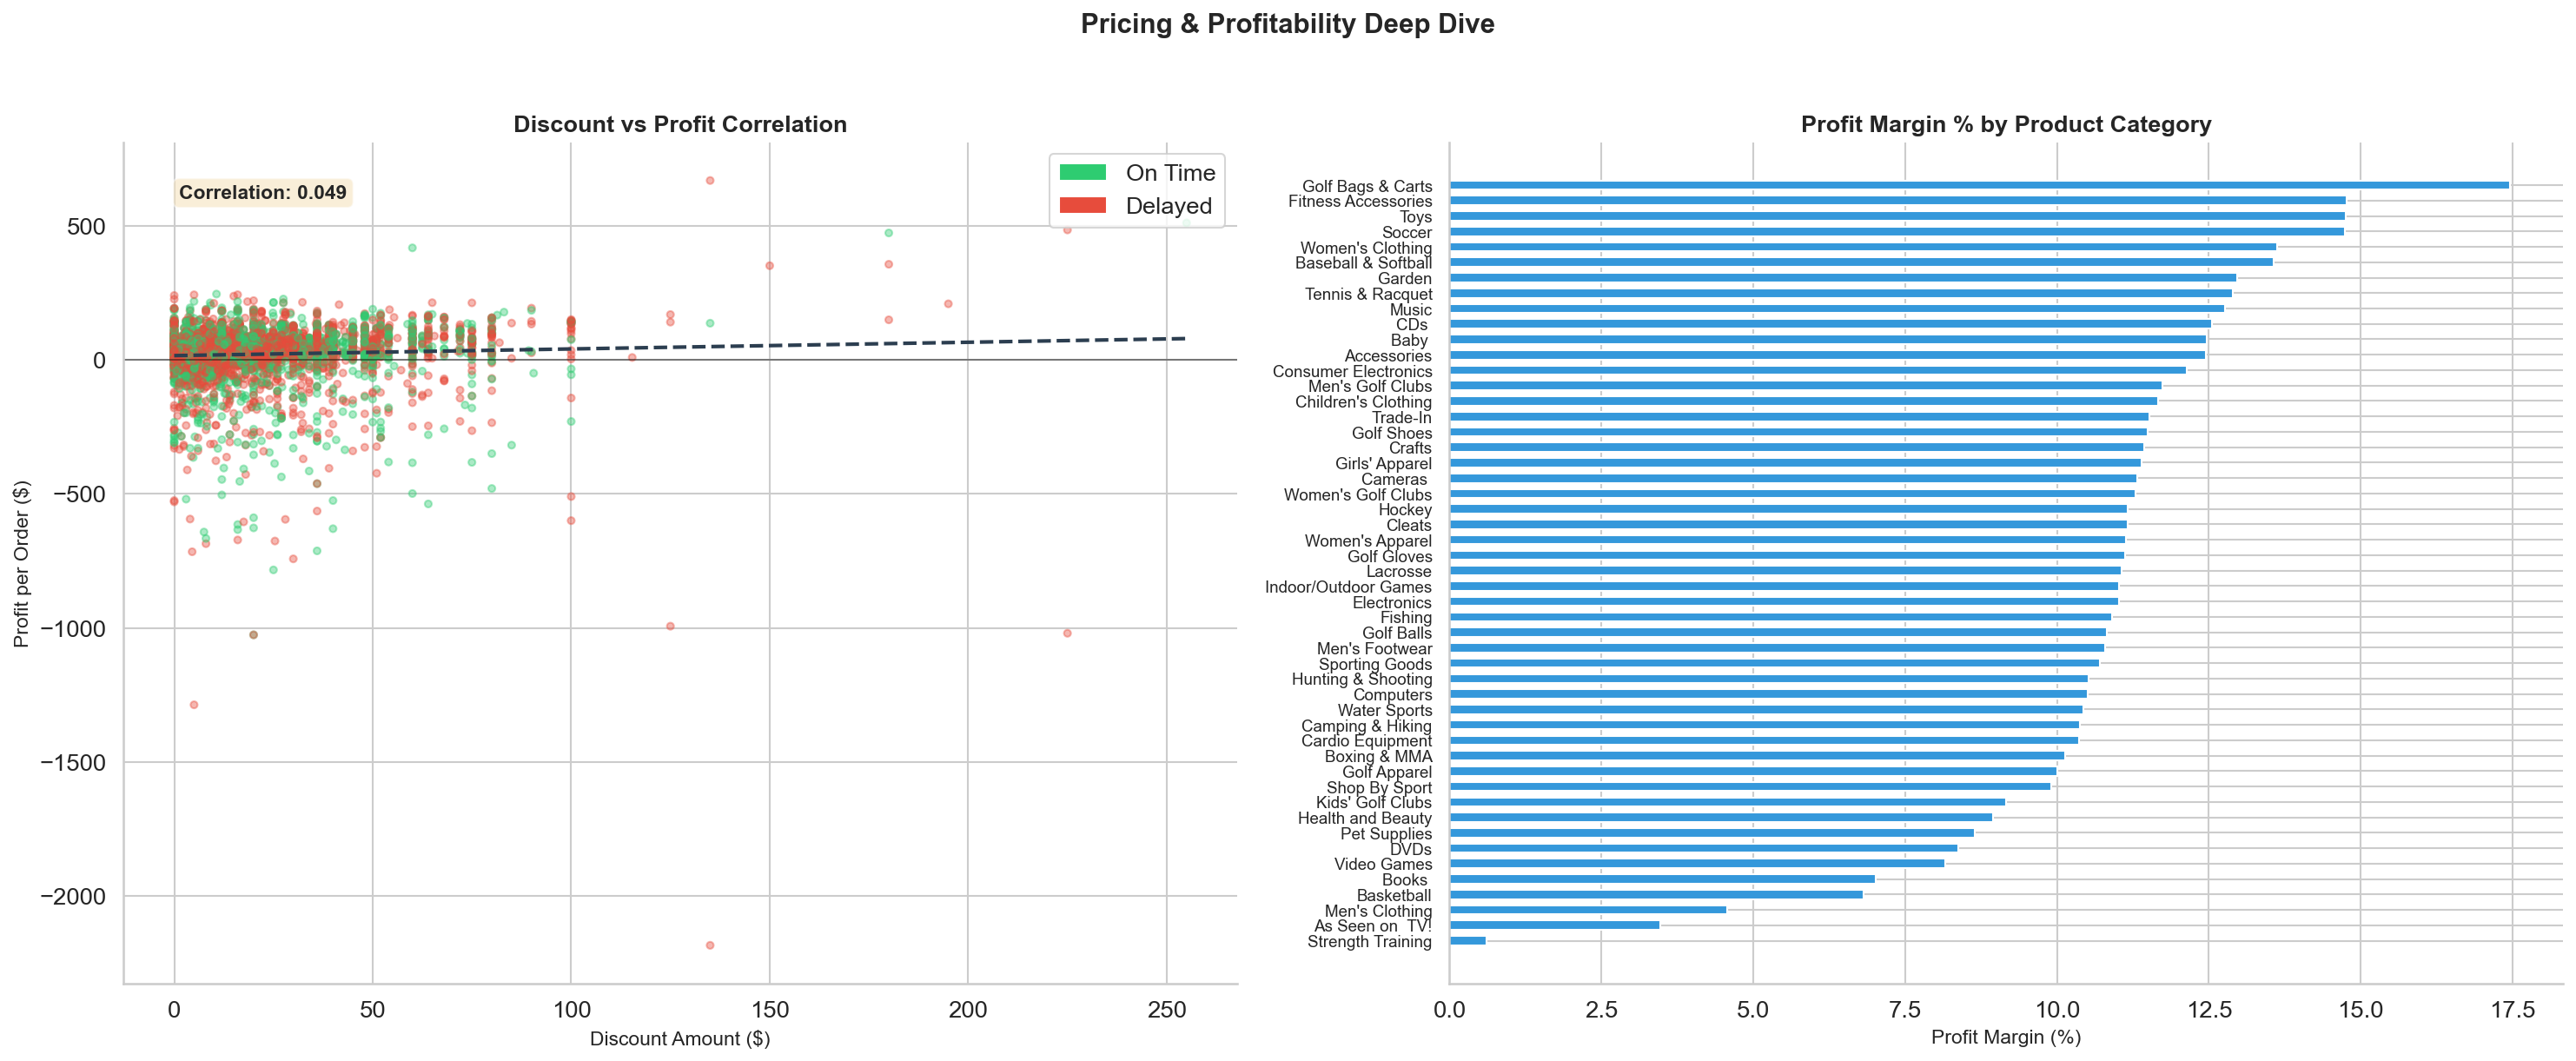

✅ Chart saved to images/


In [11]:
# ============================================================
# CELL 10: EDA Chart 6 — Discount vs Profit Correlation
# BUSINESS QUESTION: Do higher discounts actually destroy
# profit margin? This is the #1 pricing question for the CFO.
# CHART TYPE: Scatter plot with regression line
# ============================================================

# ============================================================
# CELL 10: EDA Chart 6 — Discount vs Profit Correlation
# FIX: Increased figure size and added more space for labels
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# ── LEFT CHART: Discount vs Profit scatter ──
sample = df.sample(n=5000, random_state=42)

colors = sample["is_delayed"].map({0: "#2ecc71", 1: "#e74c3c"})

axes[0].scatter(
    sample["order_item_discount"],
    sample["order_profit_per_order"],
    c=colors, alpha=0.4, s=15
)

z = np.polyfit(
    sample["order_item_discount"],
    sample["order_profit_per_order"], 1
)
p = np.poly1d(z)
x_line = np.linspace(
    sample["order_item_discount"].min(),
    sample["order_item_discount"].max(), 100
)
axes[0].plot(
    x_line, p(x_line),
    color="#2c3e50", linewidth=2,
    linestyle="--", label="Trend line"
)

corr = sample["order_item_discount"].corr(
    sample["order_profit_per_order"]
)
axes[0].text(
    0.05, 0.95,
    f"Correlation: {corr:.3f}",
    transform=axes[0].transAxes,
    fontsize=11, fontweight="bold",
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5)
)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2ecc71", label="On Time"),
    Patch(facecolor="#e74c3c", label="Delayed")
]
axes[0].legend(handles=legend_elements, loc="upper right")
axes[0].set_xlabel("Discount Amount ($)", fontsize=11)
axes[0].set_ylabel("Profit per Order ($)", fontsize=11)
axes[0].set_title(
    "Discount vs Profit Correlation",
    fontsize=13, fontweight="bold"
)
axes[0].axhline(y=0, color="black", linewidth=0.8, alpha=0.5)

# ── RIGHT CHART: Profit margin by product category ──
cat_margin = (
    df.groupby("product_category")
    .agg(
        total_revenue = ("sales_per_order",       "sum"),
        total_profit  = ("order_profit_per_order", "sum")
    )
    .reset_index()
)
cat_margin["profit_margin_pct"] = (
    cat_margin["total_profit"] /
    cat_margin["total_revenue"] * 100
).round(2)
cat_margin = cat_margin.sort_values(
    "profit_margin_pct", ascending=True
)

# ── Shorten long category names ──
cat_margin["product_category"] = (
    cat_margin["product_category"].str[:25]
)

bar_colors = [
    "#e74c3c" if x < 0 else "#3498db"
    for x in cat_margin["profit_margin_pct"]
]

axes[1].barh(
    cat_margin["product_category"],
    cat_margin["profit_margin_pct"],
    color=bar_colors, edgecolor="white", height=0.6
)
axes[1].axvline(x=0, color="black", linewidth=0.8)
axes[1].set_xlabel("Profit Margin (%)", fontsize=11)
axes[1].set_title(
    "Profit Margin % by Product Category",
    fontsize=13, fontweight="bold"
)
# ── Give labels more room ──
axes[1].tick_params(axis="y", labelsize=9)
plt.subplots_adjust(left=0.35)

plt.suptitle(
    "Pricing & Profitability Deep Dive",
    fontsize=15, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("../images/06_discount_profit_correlation.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved to images/")

In [12]:
# ============================================================
# CELL 11: Export Summary Stats for Tableau
# PURPOSE: Create aggregated CSV files that Tableau will
#          connect to directly for the dashboard
# ============================================================

print("💾 Exporting summary tables for Tableau...")

# ── 1. Monthly KPI summary ──
monthly_kpi = (
    df.groupby(["order_year", "order_month", "order_month_name"])
    .agg(
        total_revenue   = ("sales_per_order",        "sum"),
        total_profit    = ("order_profit_per_order",  "sum"),
        total_orders    = ("order_id",                "count"),
        delay_rate_pct  = ("is_delayed",              "mean"),
        avg_days_late   = ("delay_days",              "mean")
    )
    .reset_index()
)
monthly_kpi["delay_rate_pct"] = (
    monthly_kpi["delay_rate_pct"] * 100
).round(2)
monthly_kpi["profit_margin_pct"] = (
    monthly_kpi["total_profit"] /
    monthly_kpi["total_revenue"] * 100
).round(2)
monthly_kpi.to_csv(
    "../data/processed/monthly_kpi.csv", index=False
)
print("   ✅ monthly_kpi.csv saved")

# ── 2. Supplier risk scorecard ──
supplier_scorecard = (
    df.groupby(["market", "order_region", "shipping_mode"])
    .agg(
        total_orders    = ("order_id",            "count"),
        delay_rate_pct  = ("is_delayed",          "mean"),
        total_revenue   = ("sales_per_order",     "sum"),
        total_profit    = ("order_profit_per_order", "sum"),
        avg_days_late   = ("delay_days",          "mean")
    )
    .reset_index()
)
supplier_scorecard["delay_rate_pct"] = (
    supplier_scorecard["delay_rate_pct"] * 100
).round(2)
supplier_scorecard["revenue_at_risk"] = (
    supplier_scorecard["total_revenue"] *
    supplier_scorecard["delay_rate_pct"] / 100
).round(2)
supplier_scorecard["risk_score"] = (
    supplier_scorecard["delay_rate_pct"] *
    np.log(supplier_scorecard["total_orders"])
).round(2)
supplier_scorecard["risk_category"] = pd.cut(
    supplier_scorecard["delay_rate_pct"],
    bins=[0, 30, 50, 70, 100],
    labels=["Low", "Medium", "High", "Critical"]
)
supplier_scorecard.to_csv(
    "../data/processed/supplier_scorecard.csv", index=False
)
print("   ✅ supplier_scorecard.csv saved")

# ── 3. Customer segment summary ──
segment_summary = (
    df.groupby(["customer_segment", "product_category"])
    .agg(
        total_orders    = ("order_id",                "count"),
        total_revenue   = ("sales_per_order",         "sum"),
        total_profit    = ("order_profit_per_order",   "sum"),
        avg_discount    = ("order_item_discount",      "mean"),
        delay_rate_pct  = ("is_delayed",               "mean")
    )
    .reset_index()
)
segment_summary["delay_rate_pct"] = (
    segment_summary["delay_rate_pct"] * 100
).round(2)
segment_summary["profit_margin_pct"] = (
    segment_summary["total_profit"] /
    segment_summary["total_revenue"] * 100
).round(2)
segment_summary.to_csv(
    "../data/processed/segment_summary.csv", index=False
)
print("   ✅ segment_summary.csv saved")

# ── 4. Full cleaned dataset for Tableau ──
df.to_csv(
    "../data/processed/supply_chain_cleaned.csv", index=False
)
print("   ✅ supply_chain_cleaned.csv saved")

# ── Final summary ──
print("\n" + "=" * 50)
print("✅ PHASE 2 COMPLETE!")
print("=" * 50)
print(f"   Total rows processed:  {len(df):,}")
print(f"   Charts created:        6")
print(f"   CSV files exported:    4")
print(f"\n   Charts saved to:       images/")
print(f"   Data saved to:         data/processed/")
print("\n   Ready for Phase 3 — GitHub & Documentation! 🎯")

💾 Exporting summary tables for Tableau...
   ✅ monthly_kpi.csv saved
   ✅ supplier_scorecard.csv saved
   ✅ segment_summary.csv saved
   ✅ supply_chain_cleaned.csv saved

✅ PHASE 2 COMPLETE!
   Total rows processed:  180,519
   Charts created:        6
   CSV files exported:    4

   Charts saved to:       images/
   Data saved to:         data/processed/

   Ready for Phase 3 — GitHub & Documentation! 🎯
